In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Pytorch-Models

Mounted at /content/gdrive
/content/gdrive/My Drive/Pytorch-Models


In [2]:
# %pip install -qr requirements.txt # install dependencies
import torch
import os

print(f"Setup complete. Using torch {torch.__version__} ({torch.cuda.get_device_properties(0).name if torch.cuda.is_available() else 'CPU'})")


Setup complete. Using torch 2.9.0+cu126 (Tesla T4)


In [3]:
import matplotlib.pyplot as plt
import cv2
import os
import torch
from PIL import Image
import numpy as np
from torch.utils.data import Dataset
from pycocotools.coco import COCO

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


In [4]:
# Custom PyTorch Dataset to load COCO-format annotations and images
class CocoSegmentationDataset(Dataset):
    # Init function: loads annotation file and prepares list of image id's
    def __init__(self, root_dir, annotation_file, transforms=None):
        """
        root_dir: path to the folder containing images (e.g. car_parts_dataset/train/)
        annotation_file: path to the COCO annotations (e.g. car_parts_dataset/train/_annotations.coco.json)
        """
        self.root_dir = root_dir
        self.coco = COCO(annotation_file)
        self.image_ids = list(self.coco.imgs.keys())
        self.transforms = transforms

    # Returns total number of images
    def __len__(self):
        return len(self.image_ids)

    # Fetches a single image and its annotations
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_info = self.coco.loadImgs(image_id)[0]
        image_path = os.path.join(self.root_dir, image_info["file_name"])
        image = Image.open(image_path).convert("RGB")

        # Load all annotations for this image
        annotation_ids = self.coco.getAnnIds(imgIds=image_id)
        annotations = self.coco.loadAnns(annotation_ids)

         # Extract segmentation masks,bounding boxes and labels from annotations
        boxes = []
        labels = []
        masks = []

        for ann in annotations:
            xmin, ymin, w, h = ann['bbox']
            xmax = xmin + w
            ymax = ymin + h
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(ann['category_id'])
            mask = self.coco.annToMask(ann)
            masks.append(mask)

        # Convert annotations to PyTorch tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        masks = torch.as_tensor(masks, dtype=torch.uint8)
        area = torch.as_tensor([ann['area'] for ann in annotations], dtype=torch.float32)
        iscrowd = torch.as_tensor([ann.get('iscrowd', 0) for ann in annotations], dtype=torch.int64)

        # store everything in a dictionary
        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd
        }

        # Apply transforms
        if self.transforms:
            image = self.transforms(image)

         # Return the processed image and its annotations
        return image, target

In [5]:
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor

# Returns a simple transform that converts a PIL image to a PyTorch tensor
def get_transform():
    return ToTensor()

train_dataset = CocoSegmentationDataset(
    root_dir='datasets/markerpensseg/train',
    annotation_file='datasets/markerpensseg/train/_annotations.coco.json',
    transforms=get_transform()  # define this if needed
)

valid_dataset = CocoSegmentationDataset(
    root_dir='datasets/markerpensseg/valid',
    annotation_file='datasets/markerpensseg/valid/_annotations.coco.json',
    transforms=get_transform()
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

loading annotations into memory...
Done (t=3.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.82s)
creating index...
index created!


In [6]:
CLASS_NAMES = ["","CAP"]

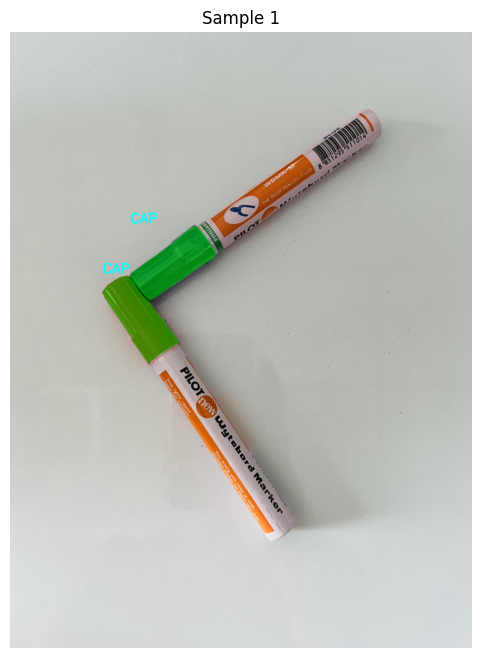

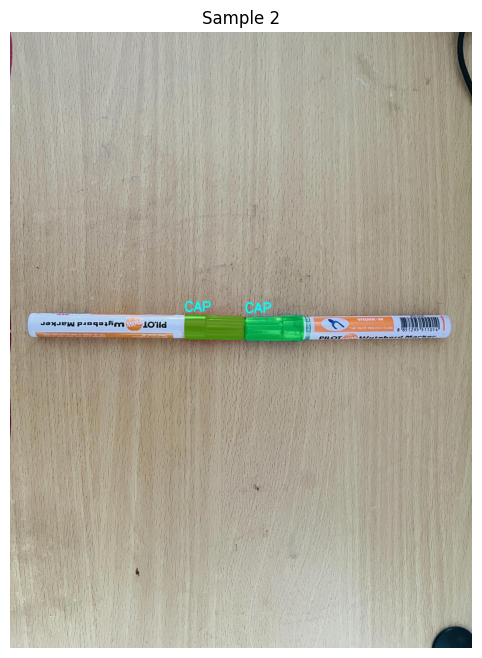

In [ ]:
# Sample a batch
images, targets = next(iter(train_loader))

for i in range(len(images)):
    # Convert image tensor to numpy array
    image = images[i].permute(1, 2, 0).cpu().numpy()
    image = (image * 255).astype(np.uint8)
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    overlay = image.copy()

    # Extract masks, bounding boxes, and labels for the current image
    masks = targets[i]['masks'].cpu().numpy()
    boxes = targets[i]['boxes'].cpu().numpy()
    labels = targets[i]['labels'].cpu().numpy()

    for j in range(len(masks)):
        mask = masks[j]
        box = boxes[j]
        label_id = labels[j]

        # Get class name from mapping
        class_name = CLASS_NAMES[label_id]

        color = [0,255,0]

        # Alpha blend mask
        colored_mask = np.zeros_like(image, dtype=np.uint8)
        for c in range(3):
            colored_mask[:, :, c] = mask * color[c]
        alpha = 0.5
        overlay = np.where(mask[..., None],
                          (((1 - alpha) * overlay) + (alpha * colored_mask)).astype(np.uint8),
                          overlay)

        # Draw label
        x1, y1, x2, y2 = map(int, box)
        cv2.putText(overlay, class_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255,255,0), 3, lineType=cv2.LINE_AA)


    # Show the result
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Sample {i + 1}")
    plt.show()

In [ ]:
import torchvision
from torchvision.models.detection import MaskRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Load a pre-trained Mask R-CNN model with a ResNet-50 FPN backbone
model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)

# Get the number of classes (including background)
num_classes = 2  # background + your classes

# 1. Replace the box predictor
in_features_box = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features_box, num_classes)

# 2. Replace the mask predictor
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

# Move the model to the device
model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth
100%|██████████| 170M/170M [00:03<00:00, 55.3MB/s]


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [ ]:
# Get parameters of model
params = [p for p in model.parameters() if p.requires_grad]

# Define the optimizer (Stochastic Gradient Descent) with learning rate, momentum, and weight decay
optimizer = torch.optim.SGD(params, lr=0.005,
                            momentum=0.9, weight_decay=0.0005)

In [ ]:
# Clone the PyTorch vision repository
!git clone https://github.com/pytorch/vision.git

# Navigate to the 'vision' directory and copy necessary detection-related utility files
!cd vision; cp references/detection/utils.py ../;  # Copy utility functions
!cd vision; cp references/detection/transforms.py ../;  # Copy image transformation functions
!cd vision; cp references/detection/coco_eval.py ../;  # Copy COCO evaluation script
!cd vision; cp references/detection/engine.py ../;  # Copy engine code for training/evaluation
!cd vision; cp references/detection/coco_utils.py ../;  # Copy COCO-specific utility functions

fatal: destination path 'vision' already exists and is not an empty directory.


In [ ]:
from engine import train_one_epoch, evaluate

# Set the number of epochs for training
num_epochs = 10

# Loop through each epoch
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    # Train the model for one epoch, printing status every 25 iterations
    train_one_epoch(model, optimizer, train_loader, device, epoch, print_freq=25)  # Using train_loader for training

    # Evaluate the model on the validation dataset
    evaluate(model, val_loader, device=device)  # Using val_loader for evaluation

    # Optionally, save the model checkpoint after each epoch
    torch.save(model.state_dict(), f"model_epoch_{epoch + 1}.pth")


Epoch 1/10


<ipython-input-4-50c2d44ca2d0>:46: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  masks = torch.as_tensor(masks, dtype=torch.uint8)
/content/gdrive/MyDrive/Pytorch-RCNN/engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [  0/113]  eta: 0:12:06  lr: 0.000050  loss: 6.0254 (6.0254)  loss_classifier: 0.6162 (0.6162)  loss_box_reg: 0.0930 (0.0930)  loss_mask: 5.1239 (5.1239)  loss_objectness: 0.1763 (0.1763)  loss_rpn_box_reg: 0.0160 (0.0160)  time: 6.4315  data: 4.3238  max mem: 2234
Epoch: [0]  [ 25/113]  eta: 0:06:20  lr: 0.001165  loss: 0.8119 (1.6418)  loss_classifier: 0.1694 (0.2625)  loss_box_reg: 0.2571 (0.2079)  loss_mask: 0.2584 (1.0550)  loss_objectness: 0.0230 (0.1062)  loss_rpn_box_reg: 0.0065 (0.0103)  time: 4.2154  data: 3.6189  max mem: 2400
Epoch: [0]  [ 50/113]  eta: 0:04:27  lr: 0.002280  loss: 0.3736 (1.0576)  loss_classifier: 0.0691 (0.1788)  loss_box_reg: 0.2330 (0.2281)  loss_mask: 0.0854 (0.5884)  loss_objectness: 0.0012 (0.0556)  loss_rpn_box_reg: 0.0021 (0.0067)  time: 4.1309  data: 3.5065  max mem: 2402
Epoch: [0]  [ 75/113]  eta: 0:02:41  lr: 0.003394  loss: 0.1988 (0.7812)  loss_classifier: 0.0341 (0.1315)  loss_box_reg: 0.0851 (0.1857)  loss_mask: 0.0713 (0.4213) 

In [9]:
from torchvision import models, transforms
import os, random, cv2
import numpy as np
import matplotlib.pyplot as plt

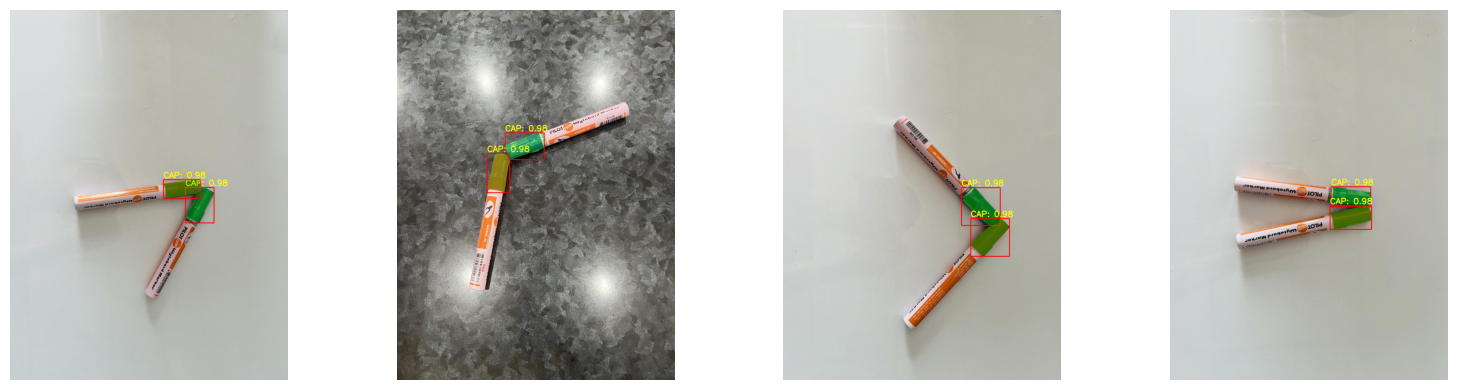

In [12]:
CLASS_NAMES = ["","CAP"]
# Load Mask R-CNN model with correct number of classes
model = models.detection.maskrcnn_resnet50_fpn(pretrained=False, num_classes=2)

# Load your trained weights
#model.load_state_dict(torch.load(r"model_epoch_10.pth", map_location=torch.device('cpu')))
model.load_state_dict(torch.load(r"test/images2/model_epoch_10.pth"))
model.eval()

# ---------------- CONFIG ----------------
val_dir = "test/images2/"

# visualization layout
N = 4
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 4 * rows))

for i, image in enumerate(sample_imgs):
    plt.subplot(1, 4, i+1)

    image_bgr = cv2.imread(image)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_pil = Image.fromarray(image_rgb)

    # Transform image to tensor and add batch dimension
    transform = transforms.Compose([transforms.ToTensor()])
    image_tensor = transform(image_pil).unsqueeze(0)

    # Inference
    with torch.no_grad():
        predictions = model(image_tensor)

    # Extract masks, boxes, labels, and scores
    masks = predictions[0]['masks']       # [N, 1, H, W]
    boxes = predictions[0]['boxes']
    labels = predictions[0]['labels']
    scores = predictions[0]['scores']

    threshold = 0.4  # Confidence threshold

    # Use overlay for blending masks over image
    overlay = image_bgr.copy()

    for ii in range(len(masks)):
        if scores[ii] > threshold:
            # Convert mask to uint8 numpy array (H,W)
            mask = masks[ii, 0].mul(255).byte().cpu().numpy()
            mask_bool = mask > 127  # binary mask for indexing
            box = boxes[ii].cpu().numpy().astype(int)
            class_name = CLASS_NAMES[labels[ii]]
            score = scores[ii].item()

            cv2.rectangle(overlay, (box[0], box[1]), (box[2], box[3]), (0, 0, 255), 3)

            # Generate color (BGR)
            color = [0,255,0]

            # Create colored mask with the random color
            colored_mask = np.zeros_like(image_bgr, dtype=np.uint8)
            for c in range(3):
                colored_mask[:, :, c] = mask_bool * color[c]

            # Alpha blend the colored mask onto the overlay
            alpha = 0.4
            overlay = np.where(mask_bool[:, :, None],
                              (((1 - alpha) * overlay) + (alpha * colored_mask)).astype(np.uint8),
                              overlay)

            # Draw bounding box and label text on overlay
            x1, y1, x2, y2 = box
            cv2.putText(overlay, f"{class_name}: {(score-0.02):.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 255), 3, lineType=cv2.LINE_AA)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 19.0 MB/s eta 0:00:00


In [14]:
dummy_input = torch.randn(1, 3, 640, 640)
onnx_model_path = "maskrcnn_seg.onnx"
torch.onnx.export(
    model,
    dummy_input,
    onnx_model_path,
    opset_version=13,
    dynamo=False,        # Use legacy exporter to avoid strict tracing issues
    input_names=["input"],
    output_names=["masks", "boxes", "labels", "scores"],
    dynamic_axes={
        "input": {0: "batch_size", 2: "height", 3: "width"},
        "masks": {0: "num_boxes"},
        "boxes": {0: "num_boxes"},
        "labels": {0: "num_boxes"},
        "scores": {0: "num_boxes"},
    },
    do_constant_folding=True,
)
print(f"ONNX export {onnx_model_path} completed successfully!")

/tmp/ipython-input-1936368346.py:3: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:4701: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  * torch.tensor(scale_factors[i], dtype=torch.float32)
/usr/local/lib/python3.12/dist-packages/tor

ONNX export maskrcnn_seg.onnx completed successfully!


In [15]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.6/252.6 MB 5.2 MB/s eta 0:00:00


In [22]:
import onnxruntime
import numpy as np
import cv2
import torch

# Load image and preprocess (assume 640x640)
img_path = "test/images/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.42ad4544fea633e89b87fdf8b4bf9d0c.jpg"

img = cv2.imread(img_path)
img_resized = cv2.resize(img, (640, 640))
img_input = img_resized.astype(np.float32) / 255.0
img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

# Run inference
session = onnxruntime.InferenceSession("maskrcnn_seg.onnx", providers=["CUDAExecutionProvider"])
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: img_input})

# outputs is a list, often like [boxes, scores, keypoints]
print("Output:", [o.shape for o in outputs])

Output: [(2, 4), (2,), (2,), (2, 1, 640, 640)]


[1 1]
[0.9999058  0.99981195]


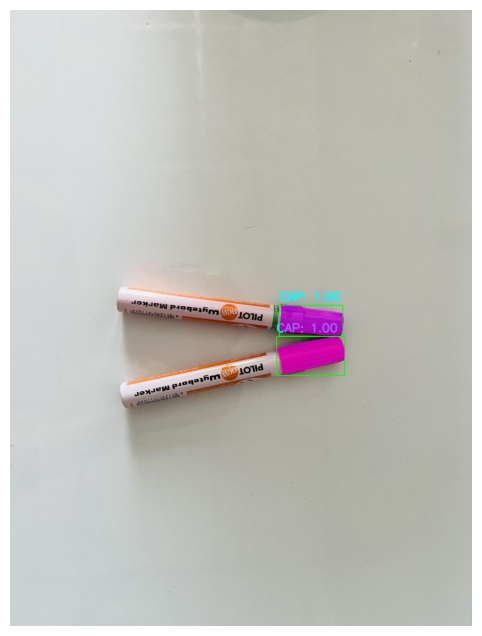

In [30]:
import torch
from torchvision.ops import nms
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Unpack outputs correctly
boxes, labels, scores, masks = outputs

# Convert to numpy arrays if needed
boxes = np.array(boxes)
labels = np.array(labels)
scores = np.array(scores)

# Apply NMS
boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
scores_tensor = torch.tensor(scores, dtype=torch.float32)
nms_indices = nms(boxes_tensor, scores_tensor, iou_threshold=0.5)

# Filter after NMS
boxes = boxes_tensor[nms_indices].numpy()
scores = scores_tensor[nms_indices].numpy()
labels = labels[nms_indices]
masks = masks[nms_indices]
print(labels)
print(scores)

# Resize back to original scale
h_orig, w_orig = img.shape[:2]
scale_x = w_orig / 640  # width scale
scale_y = h_orig / 640  # height scale

conf_thr = 0.5

for i in range(len(scores)):
    if scores[i] < conf_thr:
        continue

    # Draw bounding box
    x1, y1, x2, y2 = boxes[i]
    x1 = int(x1 * scale_x)
    y1 = int(y1 * scale_y)
    x2 = int(x2 * scale_x)
    y2 = int(y2 * scale_y)

    x1 = max(0, min(x1, w_orig - 1))
    y1 = max(0, min(y1, h_orig - 1))
    x2 = max(0, min(x2, w_orig - 1))
    y2 = max(0, min(y2, h_orig - 1))

    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    mask_640 = masks[i, 0] # Assuming shape is (1, 640, 640)
    mask_resized = cv2.resize(mask_640, (w_orig, h_orig), interpolation=cv2.INTER_LINEAR)

    # 2. Convert to binary boolean mask
    mask_bool = mask_resized > 0.5

    # Generate color (BGR)
    color = [255,0,255]

    # Create colored mask with the random color
    colored_mask = np.zeros_like(img, dtype=np.uint8)
    for c in range(3):
        colored_mask[:, :, c] = mask_bool * color[c]

    # Alpha blend the colored mask onto the overlay
    alpha = 0.4
    img = np.where(mask_bool[:, :, None],
                      (((1 - alpha) * img) + (alpha * colored_mask)).astype(np.uint8),
                      img)

# Show result
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

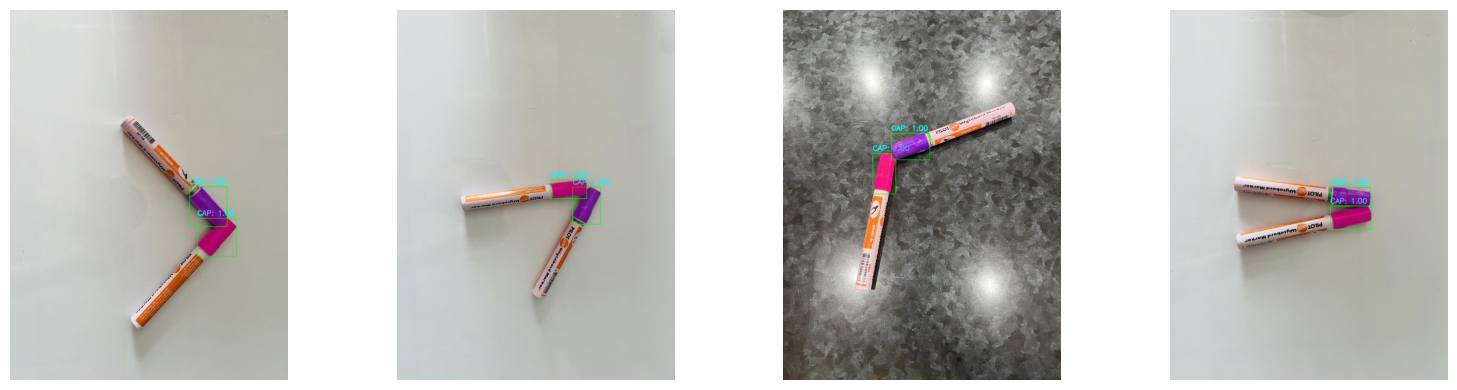

In [31]:
# class names
label_list= ["","CAP"]

session = onnxruntime.InferenceSession("maskrcnn_seg.onnx", providers=["CUDAExecutionProvider"])
input_name = session.get_inputs()[0].name

# ---------------- CONFIG ----------------
val_dir = "test/images2/"

# visualization layout
N = 4
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 4 * rows))

for i, image in enumerate(sample_imgs):
    plt.subplot(1, 4, i+1)

    img = cv2.imread(image)
    img_resized = cv2.resize(img, (640, 640))
    img_input = img_resized.astype(np.float32) / 255.0
    img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

    outputs = session.run(None, {input_name: img_input})

    boxes, labels, scores, masks = outputs

    # Convert to numpy arrays if needed
    boxes = np.array(boxes)
    labels = np.array(labels)
    scores = np.array(scores)

    # Apply NMS
    boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
    scores_tensor = torch.tensor(scores, dtype=torch.float32)
    nms_indices = nms(boxes_tensor, scores_tensor, iou_threshold=0.5)

    # Filter after NMS
    boxes = boxes_tensor[nms_indices].numpy()
    scores = scores_tensor[nms_indices].numpy()
    labels = labels[nms_indices]
    masks = masks[nms_indices]

    # Resize back to original scale
    h_orig, w_orig = img.shape[:2]
    scale_x = w_orig / 640  # width scale
    scale_y = h_orig / 640  # height scale

    conf_thr = 0.5

    for ii in range(len(scores)):
        if scores[ii] < conf_thr:
            continue

        label = label_list[labels[ii]]
        score = scores[ii]

        # Draw bounding box
        x1, y1, x2, y2 = boxes[ii]
        x1 = int(x1 * scale_x)
        y1 = int(y1 * scale_y)
        x2 = int(x2 * scale_x)
        y2 = int(y2 * scale_y)

        x1 = max(0, min(x1, w_orig - 1))
        y1 = max(0, min(y1, h_orig - 1))
        x2 = max(0, min(x2, w_orig - 1))
        y2 = max(0, min(y2, h_orig - 1))

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        mask_640 = masks[ii, 0] # Assuming shape is (1, 640, 640)
        mask_resized = cv2.resize(mask_640, (w_orig, h_orig), interpolation=cv2.INTER_LINEAR)

        # 2. Convert to binary boolean mask
        mask_bool = mask_resized > 0.5

        # Generate color (BGR)
        color = [255,0,255]

        # Create colored mask with the random color
        colored_mask = np.zeros_like(img, dtype=np.uint8)
        for c in range(3):
            colored_mask[:, :, c] = mask_bool * color[c]

        # Alpha blend the colored mask onto the overlay
        alpha = 0.4
        img = np.where(mask_bool[:, :, None],
                          (((1 - alpha) * img) + (alpha * colored_mask)).astype(np.uint8),
                          img)

        # draw label and score
        text = f"{label}: {score:.2f}"
        cv2.putText(img, text, (x1, y1 - 15), cv2.FONT_HERSHEY_SIMPLEX,
                    1.3, (255, 255, 0), 3, cv2.LINE_AA)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()